In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# ====== CONFIG ======
SAVE_DIR = "/common/users/sl2148/Public/yang_ouyang/projects/lm-evaluation-harness/lm_eval/models/eval_grid_less_tokens_3B_lib_manual_same_lib_1000samples copy/prm_results"
RESULTS_JSON = os.path.join(SAVE_DIR, "results_merged.json")
OUT_DIR = os.path.join(SAVE_DIR, "special")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_ACC = os.path.join(OUT_DIR, "acc_vs_lambda.png")
OUT_NLL = os.path.join(OUT_DIR, "nll_vs_lambda.png")

In [3]:
def _sorted_lams(layer_dict):
    lams = []
    for k in layer_dict.keys():
        try:
            lams.append(float(k))
        except Exception:
            pass
    if lams:
        return sorted(lams)

    if "BASELINE" in layer_dict:
        return [0.0]

    return []


def _get_entry(layer_dict, lam_float):
    for key in (
        str(lam_float),
        f"{lam_float}",
        f"{lam_float:.1f}",
        f"{lam_float:.2f}",
        f"{lam_float:.3f}",
    ):
        if key in layer_dict:
            return layer_dict[key]

    if lam_float == 0.0 and "BASELINE" in layer_dict:
        return layer_dict["BASELINE"]

    for k, v in layer_dict.items():
        try:
            if float(k) == lam_float:
                return v
        except Exception:
            continue

    raise KeyError(f"Cannot find entry for lam={lam_float}")


def _compute_acc(entry):
    return float(np.mean(np.array(entry["Y"], dtype=float)))


def _compute_nll(entry):
    ppl = entry.get("ppl")
    if ppl is None:
        return None

    if isinstance(ppl, (list, tuple, np.ndarray)):
        if len(ppl) == 0:
            return None
        ppl_mean = float(np.mean(np.array(ppl, dtype=float)))
    else:
        ppl_mean = float(ppl)

    return float(np.log(ppl_mean))

In [4]:
def _setup_rcparams():
    plt.rcParams.update({
        "font.size": 20,
        "axes.labelsize": 20,
        "legend.fontsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
    })

In [5]:
def plot_metric_vs_lambda(raw, metric_name, y_label, out_path):
    """
    metric_name: "acc" or "nll"
    """
    _setup_rcparams()

    fig, ax = plt.subplots(figsize=(9, 6))

    all_models = list(raw.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(all_models))))
    model2color = {m: colors[i] for i, m in enumerate(all_models)}

    markers = ["o", "s", "^", "D", "P", "X", "<", ">", "v", "*"]

    handles, labels = [], []
    seen = set()

    for mi, (model_name, model_data) in enumerate(raw.items()):
        short_m = model_name.split("/")[-1]

        layers = list(model_data.keys())
        try:
            layers = sorted(layers, key=lambda x: int(x))
        except Exception:
            layers = sorted(layers, key=lambda x: str(x))

        for li, L in enumerate(layers):
            layer_dict = model_data[L]
            lams = _sorted_lams(layer_dict)
            if not lams:
                continue

            xs, ys = [], []
            for lam in lams:
                entry = _get_entry(layer_dict, lam)
                if metric_name == "acc":
                    xs.append(lam)
                    ys.append(_compute_acc(entry))
                elif metric_name == "nll":
                    nll = _compute_nll(entry)
                    if nll is None:
                        continue
                    xs.append(lam)
                    ys.append(nll)

            label = f"{short_m}-L{L}"
            if label in seen:
                label = None
            else:
                seen.add(label)

            line, = ax.plot(
                xs, ys,
                marker=markers[li % len(markers)],
                linewidth=2.0,
                markersize=7,
                color=model2color[model_name],
                alpha=0.9,
                label=label
            )

            if label is not None:
                handles.append(line)
                labels.append(label)

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.3)

    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=min(3, max(1, len(labels))),
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(out_path, dpi=400, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [6]:
with open(RESULTS_JSON, "r") as f:
    raw = json.load(f)

print("Models:", list(raw.keys()))

Models: ['Qwen2.5-3B-Instruct']


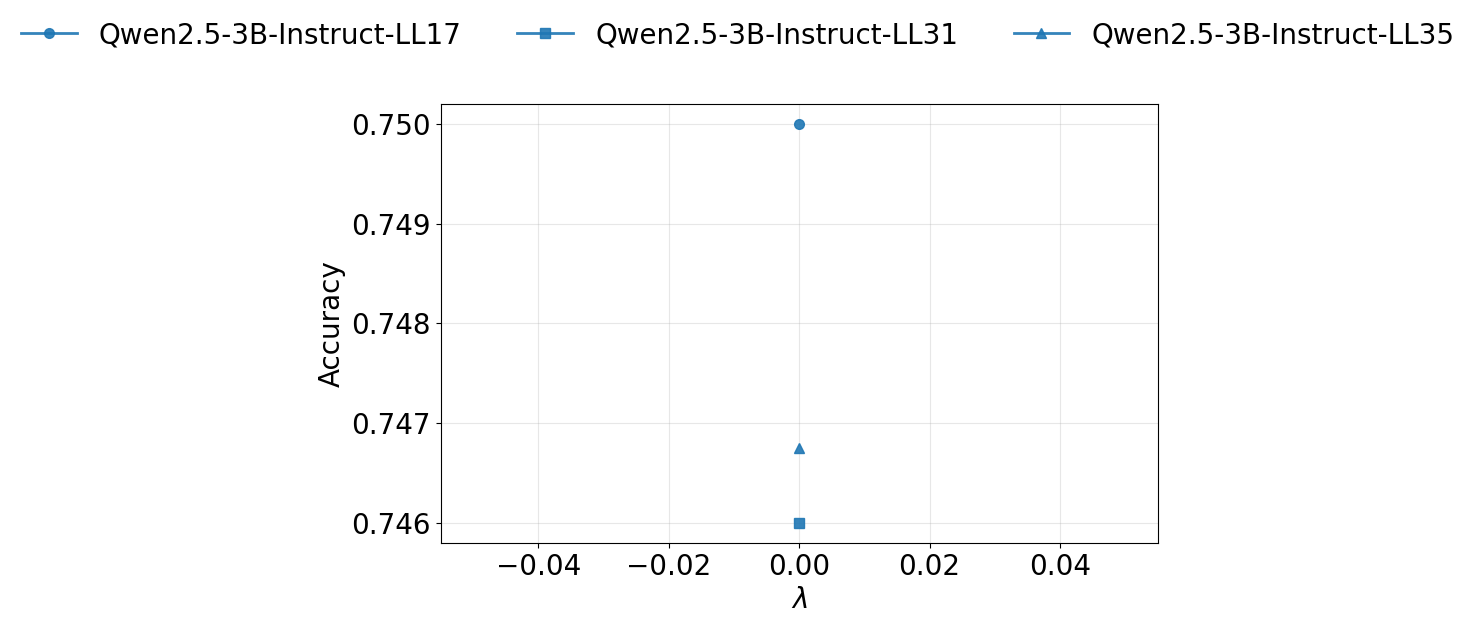

Saved: /common/users/sl2148/Public/yang_ouyang/projects/lm-evaluation-harness/lm_eval/models/eval_grid_less_tokens_3B_lib_manual_same_lib_1000samples copy/prm_results/special/acc_vs_lambda.png


In [7]:
plot_metric_vs_lambda(
    raw,
    metric_name="acc",
    y_label="Accuracy",
    out_path=OUT_ACC
)